# CBA on the Effects of Air Pollution

The following code performs a CBA on the effects of air pollution on varying aspects of society

## Imports

Packages and input files are imported to be used further down in the code


In [148]:
# Import neccessary packages
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

### General

In [149]:
# AP costs
AP_costs = pd.read_excel("Output/APcosts_check.xlsx")

# Economic regions
region_df = pd.read_excel("Output/region_allocation_check.xlsx")

In [150]:
region_df["Region"].unique()

<StringArray>
[                 'EU27',                 'EECCA',                  'EFTA',
          'UNECE Europe', 'UNECE Caucasus + Asia',        'Western Balkan',
              'NON EU27',               'Nordics',          'Pan-European']
Length: 9, dtype: str

### Climate

In [151]:
# Stressor
emissions_input = pd.read_excel("Output/emissions_check.xlsx")

# Impact
climate_metric = pd.read_excel("Output/Metric_check.xlsx")

# Economic Values
SC_SLCP = pd.read_excel(r"Output/SLCF_cost_check.xlsx")

In [152]:
emissions_input["Scenario"].unique()

<StringArray>
[   'Base_v6b', 'A1r/d/D/v6b',  'C1/d/D/v6b',  'D1/d/D/v6b',  'C2/d/D/v6b',
  'D2/d/D/v6b',  'D3/d/D/v6b',    'MTFR_v6b']
Length: 8, dtype: str

### Health

In [153]:
# Stressors
PM25_input = pd.read_excel("Output/PM25_check.xlsx")

# State
Inc_R_morb = pd.read_excel("Output/Morb_incidents.xlsx")
Inc_R_mort = pd.read_excel("Output/Mort_incidents.xlsx")
pop = pd.read_excel("Output/POP_5yr.xlsx")
LE_30 = pd.read_excel("Output/LE_5yr.xlsx")

# Impacts
health_ERF = pd.read_excel("Output/Health_ERF_check.xlsx")

# Economic Values
morb_costs = pd.read_excel("Output/Morb_costs_check.xlsx")
VOLY_VSL_costs = pd.read_excel("Output/Mort_costs_check.xlsx")

In [154]:
PM25_input["Scenario"].unique()

<StringArray>
[   'Base_v6b', 'A1r/d/D/v6b',  'C1/d/D/v6b',  'C2/d/D/v6b',  'D1/d/D/v6b',
  'D2/d/D/v6b',  'D3/d/D/v6b',    'MTFR_v6b']
Length: 8, dtype: str

### Fertilisation

In [155]:
# Stressors


# State
Ne_to_N = 0.014

# Impacts
BIO_CL = pd.read_excel("Output/BIO_CL_check.xlsx")

# Economic Values €/kg N
Price_N = 1.550

In [156]:
BIO_CL["Scenario"].unique()

<StringArray>
[   'Base_v6b', 'A1r/d/D/v6b',  'C1/d/D/v6b',  'C2/d/D/v6b',  'D1/d/D/v6b',
  'D2/d/D/v6b',  'D3/d/D/v6b',    'MTFR_v6b']
Length: 8, dtype: str

### Biodiversity

In [157]:
# Stressors


# State
# Ne_to_N = 0.014

# Impacts
BIO_CL_biodiv = pd.read_excel("Output/BIO_CL_check.xlsx")

# Economic Values

# €/kg N
Brink = pd.DataFrame({
    "Biodiv_level": ["Low","High"],
    "Economic_value": [2.3, 11.3]    
})

# €/1000 km2
Hasler = pd.DataFrame({
    "Biodiv_level": ["Low","High"],
    "Economic_value": [4500000, 13500000]    
})


### Crops

In [158]:
# Impacts
crops_avoided_losses = pd.read_excel("Output/crops_out_check.xlsx")

# Economic Values euro [€/tonne] (See ICP Vegatation)
crops_econ_input = [
    {"Crop": "Potato", "low": 20, "mid": 36.1, "high": 50},
    {"Crop": "Wheat", "low": 100, "mid": 219.5, "high": 300}
]

crops_econ_values = pd.DataFrame(crops_econ_input)

In [159]:
crops_avoided_losses["Scenario"].unique()

<StringArray>
[   'Base_v6b', 'A1r/d/D/v6b',  'C1/d/D/v6b',  'D1/d/D/v6b',  'C2/d/D/v6b',
  'D2/d/D/v6b',  'D3/d/D/v6b',    'MTFR_v6b']
Length: 8, dtype: str

## Functions

Gather all functions which are to be used later in the CBA

In [160]:
# Merge tables by KEY through

# Sequentially merge all parameter DataFrames using only the shared context keys
# (country, scenario, year). Each DataFrame can contain multiple variants
# (level/type_of_value) per key, so the merge behaves as a many-to-many join,
# generating all valid parameter combinations within each context.

def many_to_many(KEYS, dfs, how, suffixes):
    out = reduce(lambda left_table, right_table: left_table.merge(right_table, on=KEYS, how=how, suffixes=(suffixes)), dfs)

    return(out)


## Define Global Parameters
Define for example economic regions by creating lists to call for later.

### General

<div class="alert alert-block alert-success">
<b>Check:</b> ÄNDRA SCENARIORNA NEDAN IFALL NYA SÅDANA ANVÄNDS
</div>

In [161]:
Countries = region_df["Country"].unique()

Regions = ['Country', 'EU27', 'EECCA', 'EFTA', 'UNECE Europe', 'UNECE Caucasus + Asia', 'Western Balkan', 'NON EU27', 'Nordics']

Scenarios = ["A1r/d/D/v6b", "C1/d/D/v6b", "D1/d/D/v6b", "C2/d/D/v6b", "D2/d/D/v6b", "D3/d/D/v6b", "MTFR_v6b"]
# Scenarios = ['A1/d/D/v5a', 'A1/d/G/v5a', 'A1/s/D/v5a', 'A1/s/G/v5a',
#        'A1r/d/D/v5a', 'A1r/d/G/v5a', 'A1r/s/D/v5a', 'A1r/s/G/v5a',
#        'A2/d/D/v5a', 'A2/s/D/v5a', 'A3/d/D/v5a', 'A3/s/D/v5a',
#        'A4/s/D/v5a', 'B1/d/D/v5a', 'B2/d/D/v5a']


BASE_Scenario = "Base_v6b" 
# BASE_Scenario = "Base_v5a"

Levels = ['Low', 'Mid', 'High']

### Climate

In [162]:
Pollutants = ['SO2', 'NOx', 'NH3', 'NMVOC', 'PM2.5', 'BC', 'CH4', 'PMres']

Climate_metrics = ['GWP20-E', 'GWP100-E', 'GTP20-E', 'GTP100-E']

### Health

In [163]:
Core = ['Core', 'Non-core']

Mor_cause = ["All", "Specfic"]

Mor_model = ["GAINS", "ARP"]

Cost_type = ['VOLY', 'VSL']

### Crops

In [164]:
Crop_types = ["Wheat", "Potato"]

## Prepping

In order to conduct the CBA on all possible permutations, the input dataframes has to be prepped.

The code must:
1. Allow the user to choose values for certain parameters
2. Ensure traceability after permutations

### General

In [165]:
# Only use the sum of sectors
AP_costs_sector = AP_costs[AP_costs['Sector'] == 'Sum']

# Remove second column of Net AP costs
AP_costs_sector_drop = AP_costs_sector.drop(columns=["Net_AP_Costs"])

# Merge and sum by economic region
AP_costs_ByRegion = many_to_many("Country", [region_df, AP_costs_sector_drop], "left", ["",""])
AP_costs_ByRegion = AP_costs_ByRegion.groupby(["Region", "Scenario", "Sector" , "Year"], as_index=False)["Net AP Costs"].sum()
AP_costs_ByRegion["Country"] = "NA"

# 
AP_costs_ByCountry = AP_costs_sector_drop.copy()
AP_costs_ByCountry["Region"] = "Country"

#
AP_costs_tomerge = pd.concat([AP_costs_ByCountry, AP_costs_ByRegion], ignore_index=True)
AP_costs_tomerge = AP_costs_tomerge[["Region", "Country", "Scenario", "Net AP Costs"]]

In [166]:
AP_costs_tomerge["Region"].unique()

<StringArray>
[              'Country',                 'EECCA',                  'EFTA',
                  'EU27',              'NON EU27',               'Nordics',
          'Pan-European', 'UNECE Caucasus + Asia',          'UNECE Europe',
        'Western Balkan']
Length: 10, dtype: str

### Climate

In [167]:
# Only use the sum of sectors
emissions_input_sector = emissions_input[emissions_input['Sector'] == 'Sum']

# Only use the year 2040
emissions_input_sector_year = emissions_input_sector[emissions_input_sector['Year'] == 2040]
SC_SLCP_year = SC_SLCP[SC_SLCP['Year'] == 2040]
SC_SLCP_year_drop = SC_SLCP_year.drop(columns=["Year"])

# Only use the discount rate of 0.020
SC_SLCP_year_discount = SC_SLCP_year_drop[SC_SLCP_year_drop['Discount rate'] == 0.020]

### Health

In [168]:
# Only use the 'All' of age groups
pop_age = pop[pop['5yr cohort'].isin(['Total', '30-34',
       '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69',
       '70-74', '75-79', '80-84', '85-89', '90-94', '95+'])]

health_ERF_age = health_ERF[health_ERF['Age group'] == '30+']

Inc_R_morb_age = Inc_R_morb.loc[Inc_R_morb["5yr cohort"].isin(['30-34',
       '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69',
       '70-74', '75-79', '80-84', '85-89', '90-94', '95+'])]
Inc_R_mort_age = Inc_R_mort.loc[Inc_R_mort["5yr cohort"].isin(['30-34',
       '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69',
       '70-74', '75-79', '80-84', '85-89', '90-94', '95+'])]

# Only use the year 2040
pop_age_year = pop_age[pop_age['Year'] == 2040]
LE_30_year = LE_30[LE_30['Year'] == 2040]
Inc_R_mort_age_year = Inc_R_mort_age[Inc_R_mort_age['Year'] == 2040]

# YOLL or Mean conc
PM25_input_mean = PM25_input.drop(columns=["YOLL_value", "Premat_deaths"])
PM25_input_yoll = PM25_input.drop(columns=["Mean PM2.5 concentration_value", "Premat_deaths"])
PM25_input_prem_deaths = PM25_input.drop(columns=["Mean PM2.5 concentration_value", "YOLL_value"])

#
VOLY_costs = VOLY_VSL_costs[VOLY_VSL_costs["Cost_type"] == "VOLY"]
VSL_costs = VOLY_VSL_costs[VOLY_VSL_costs["Cost_type"] == "VSL"]

### Fertilisation

In [169]:
# Only use forests
BIO_CL_forests = BIO_CL.loc[BIO_CL['Ecosystem_type'] == "Forest"]

# Splice the df into Base vs other scenarios
BIO_CL_scen = BIO_CL_forests.loc[BIO_CL_forests['Scenario'].isin(Scenarios)]
BIO_CL_base = (BIO_CL_forests[BIO_CL_forests['Scenario'] == BASE_Scenario]).drop(columns=["Area", "Exceeded"])

# Match rows between base and other scenarios and clean
BIO_CL_prepped = many_to_many(["Region","Country", "Year", "Ecosystem_type"], [BIO_CL_scen, BIO_CL_base], "inner", ["_scen", "_base"])  
BIO_CL_prepped = BIO_CL_prepped.drop(columns = ["Scenario_base"]).rename(columns={'Scenario_scen': 'Scenario'})

### Crops

In [170]:
# Melting the df as to only have one Delta column
crops_econ_values_long = crops_econ_values.melt(
    id_vars=['Crop'],
    var_name="Econ_level",
    value_name="Econ_value"
)

## Combining

Sequentially merge all parameter DataFrames using only the shared context keys and keep all columns to ensure tracebility. 

The code builds upon the "many-to-many merge problem" and uses Cartisian product.

### Climate

In [171]:
# Create the KEY which matches rows between dfs
KEYS_em = ["Pollutant"]

# Merge all dfs pertaining to the Climate CBA using the correct KEY
out_em = many_to_many(KEYS_em, [emissions_input_sector_year, 
                                climate_metric,              
                                SC_SLCP_year_discount], "inner", ["",""]) 

### Health

In [172]:
# Create the KEYS which matches rows between dfs. Different KEYS are required for each merging step
KEYS_pm_1 = ["Country", "Year", "5yr cohort"]
KEYS_pm_2 = ["Health_outcome"]
KEYS_pm_3 = ["Country", "Year"]

# Merge all dfs pertaining to MORBIDITY
out_morb_1 = many_to_many(KEYS_pm_1, [pop_age_year, Inc_R_morb_age], "inner", ["",""])
out_morb_2 = many_to_many(KEYS_pm_2, [out_morb_1, health_ERF_age], "inner", ["",""]) # Assume ERF true and homogenous for all cohorts within 30+ age group
out_morb_3 = many_to_many(KEYS_pm_3, [out_morb_2, PM25_input_mean], "inner", ["",""])

# Merge all dfs pertaining to MORTALITY
out_mort_1 = many_to_many(KEYS_pm_1, [pop_age_year, Inc_R_mort_age_year], "inner", ["",""])
out_mort_2 = many_to_many(KEYS_pm_2, [out_mort_1, health_ERF_age], "inner", ["",""]) # Assume ERF true and homogenous for all cohorts within 30+ age group
out_mort_3 = many_to_many(KEYS_pm_3, [out_mort_2, PM25_input_mean], "inner", ["",""])

### Fertilisation

In [173]:
# Merge all dfs pertaining to the Fertilisation CBA
BIO_CL_prepped["Ne to N"] = Ne_to_N
BIO_CL_prepped["Price N"] = Price_N

## Computing

Compute the results of all values within a row and insert a Results column. 

The equation used to compute each row depends on the CBA sub-category.

### Climate

Eq:

$$
\text{Impact} =
\text{Emissions} \cdot \text{Climate Metric} \cdot \text{Economic Metric}
$$

Where:

- $\text{Emissions}$ = amount of pollutant present in atmosphere  
- $\text{Climate Metric}$ = conversion metric to find the climate forcing value  
- $\text{Economic Metric}$ = economic values per tCO2  

In [174]:
# Collect all columns holding parameter values
value_cols_em = [c for c in out_em.columns if c.endswith("_value")]

# Compute the result for each permutation by multiplying all parameter values row-wise according to the Climate-equation
out_em["Results"] = out_em[value_cols_em].prod(axis=1)

Eq 2:

$$
\text{Benefits}_{\text{Climate}} = \text{Impact (Base)} - \text{Impact (Scenario)}_{\text{i}}
$$


In [175]:
#KEYS for further matching between dataframes
KEYS_em_delta = ["Region", "Country", "Climate_metric", "Level"]

# Group the Climate results by country, sum accross all pollutants
out_em_country = (out_em.groupby(["Region", "Country", "Scenario", "Climate_metric", "Level"], as_index=False)["Results"].sum())

# Split the df by BaseV6 scenario from the others
out_em_country_base = out_em_country[out_em_country['Scenario'] == BASE_Scenario]
out_em_country_scenarios = out_em_country.loc[out_em_country['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_em_delta
out_em_delta = many_to_many(KEYS_em_delta, [out_em_country_scenarios, out_em_country_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_em_delta["Benefits"] = out_em_delta["Results_base"] - out_em_delta["Results_scen"]

# Rename one scenario column
out_em_delta = out_em_delta.rename(columns={'Scenario_scen': 'Scenario'})

# Split for region allocation
out_em_delta_country = out_em_delta[out_em_delta["Region"] == "Country"].copy()
out_em_delta_region = out_em_delta[out_em_delta["Region"] != "Country"].copy()

# Group the benefits in _regions by region, thus sum all countries within the two.
out_em_region = out_em_delta_region.groupby(["Region", "Scenario", "Climate_metric", "Level"], as_index=False)["Benefits"].sum()

# Merge again
Climate_benefits = pd.concat([out_em_delta_country, out_em_region], ignore_index=True)

# Remove NaN 
Climate_benefits["Country"] = Climate_benefits["Country"].fillna("NA")
Climate_benefits = Climate_benefits.rename(columns={"Benefits": "Benefits_climate"})

# Re-order
Climate_benefits = Climate_benefits[["Region", "Country", "Scenario", "Climate_metric", "Level", "Benefits_climate"]]

In [176]:
Climate_benefits["Region"].unique()

<StringArray>
[              'Country',                 'EECCA',                  'EFTA',
                  'EU27',              'NON EU27',               'Nordics',
          'Pan-European', 'UNECE Caucasus + Asia',          'UNECE Europe',
        'Western Balkan']
Length: 10, dtype: str

#### Per Pollutant

In [177]:
#KEYS for further matching between dataframes
KEYS_em_delta_poll = ["Region", "Country", "Climate_metric", "Level", "Pollutant"]

# Group the Climate results by country, sum accross all pollutants
out_em_country_poll = (out_em.groupby(["Region", "Country", "Scenario", "Pollutant", "Climate_metric", "Level"], as_index=False)["Results"].sum())

# Split the df by BaseV6 scenario from the others
out_em_country_base_poll = out_em_country_poll[out_em_country_poll['Scenario'] == BASE_Scenario]
out_em_country_scenarios_poll = out_em_country_poll.loc[out_em_country_poll['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_em_delta
out_em_delta_poll = many_to_many(KEYS_em_delta_poll, [out_em_country_scenarios_poll, out_em_country_base_poll], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_em_delta_poll["Benefits"] = out_em_delta_poll["Results_base"] - out_em_delta_poll["Results_scen"]

# Rename one scenario column
out_em_delta_poll = out_em_delta_poll.rename(columns={'Scenario_scen': 'Scenario'})

# Split for region allocation
out_em_delta_country_poll = out_em_delta_poll[out_em_delta_poll["Region"] == "Country"].copy()
out_em_delta_region_poll = out_em_delta_poll[out_em_delta_poll["Region"] != "Country"].copy()

# Group the benefits in _regions by region, thus sum all countries within the two.
out_em_region_poll = out_em_delta_region_poll.groupby(["Region", "Scenario", "Pollutant", "Climate_metric", "Level"], as_index=False)["Benefits"].sum()

# Merge again
Climate_benefits_poll = pd.concat([out_em_delta_country_poll, out_em_region_poll], ignore_index=True)

# Remove NaN 
Climate_benefits_poll["Country"] = Climate_benefits_poll["Country"].fillna("NA")
Climate_benefits_poll = Climate_benefits_poll.rename(columns={"Benefits": "Benefits_climate"})

# Re-order
Climate_benefits_poll = Climate_benefits_poll[["Region", "Country", "Scenario", "Pollutant", "Climate_metric", "Level", "Benefits_climate"]]


### Health

#### ARP
Eq 1:

$$
\text{Impact}_{\text{Deaths/Cases}} =
\text{POP} \cdot \text{Inc\_R}
\left(
1 - e^{\frac{-\ln(\text{ERF})}{10}\cdot \Delta C}
\right)
$$


Where:

- $\text{POP}$ = affected population (within a specific 5 year age cohort)  
- $\text{Inc\_R}$ = Incidence rate, cases per 100,000 persons (within a specific 5 year age cohort)  
- $\text{ERF}$ = Exposure–Response Function, relative risk (RR) per $10\,\mu g/m^3$ exposure increment  
- $\Delta C$ = change in exposure, $\mu g/m^3$


In [178]:
# MORBIDITY
# Compute the result for each permutation by multiplying all parameter values row-wise according to the Health-equation 
out_morb_3["Cases"] = (
    (out_morb_3["pop_value"]/100000)
    * out_morb_3["Morb_value"]
    * (
        1
        - np.exp(
            (-np.log(out_morb_3["Effect_value"]) / 10)
            * out_morb_3["Mean PM2.5 concentration_value"]
        )
    )
)


#MORTALITY
# Compute the result for each permutation by multiplying all parameter values row-wise according to the Health-equation 
out_mort_3["Deaths"] = (
    (out_mort_3["pop_value"]/100000)
    * out_mort_3["Mort_value"]
    * (
        1
        - np.exp(
            (-np.log(out_mort_3["Effect_value"]) / 10)
            * out_mort_3["Mean PM2.5 concentration_value"]
        )
    )
)



Eq 2 Mortality:

$$
\text{YOLL} = \text{Impact}_{\text{Deaths}} \cdot \text{LE} 
$$

Where:

- $\text{YOLL}$ = Years of Life Losts
- $\text{LE}$ = Life expectancy of affected population (within a specific 5 year age cohort)  


$$
\text{Benefits}_{\text{Mortality}}(YOLL) = (\text{YOLL (Base)} - \text{YOLL (Scenarios)}) \cdot \text{VOLY} 
$$
$$
\text{Benefits}_{\text{Mortality}}(Deaths) = (\text{Impact (Base)}_{\text{Deaths}} - \text{Impact (Scenarios)}_{\text{Deaths}}) \cdot \text{VSL} 
$$

Where:

- $\text{VOLY}$ = Value of Life Year, per years of life lost and region/country
- $\text{VSL}$ = Value of Statistical Life, per life lost and region/country 

Eq 2 Morbidity:

$$
\text{Benefits}_{\text{Morbidity}} = (\text{Impact (Base)}_{\text{Cases}} - \text{Impact (Scenarios)}_{\text{Cases}}) 
\cdot \text{Morb\_C}
$$

Where:

- $\text{Morb\_C}$ = Economic valuation of morbidity case, per health outcome, country, and evaluation type (Healthcare, Disultility, Productivity loss)  

In [179]:
# MORTALITY

# Add LE
KEYS_mort_4 = ["Country", "Year", "5yr cohort"]
out_mort_4 = many_to_many(KEYS_mort_4, [out_mort_3, LE_30_year], "inner", ["",""])

# Multiply LE with 
out_mort_4["YOLL"] = out_mort_4["Deaths"] * out_mort_4["LE_value"]

out_mort_4_test = out_mort_4.copy()

# Group 5yr cohorts into one age group 30+
out_mort_4 = out_mort_4.groupby(["Region", "Country", "Scenario", "Health_outcome", 
                                 "Mort_level", "Core", "Age group", "Effect_level", "Mor_cause"], as_index=False)[
                                ["Deaths", "YOLL"]].sum()

# Split base and scenarios

# KEYS for further matching between dataframes
KEYS_mort_delta = ["Region", "Country", "Health_outcome", 
                 "Mort_level", "Core", "Age group", "Effect_level", "Mor_cause"]

# Split the df by BaseV6 scenario from the others
out_mort_base = out_mort_4[out_mort_4['Scenario'] == BASE_Scenario]
out_mort_scenarios = out_mort_4.loc[out_mort_4['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_pm_delta
out_mort_delta = many_to_many(KEYS_mort_delta, [out_mort_scenarios, out_mort_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_mort_delta["Delta_Deaths"] = out_mort_delta["Deaths_base"] - out_mort_delta["Deaths_scen"]
out_mort_delta["Delta_YOLL"] = out_mort_delta["YOLL_base"] - out_mort_delta["YOLL_scen"]

# Rename one scenario column
out_mort_delta = out_mort_delta.rename(columns={'Scenario_scen': 'Scenario'})

# Melting the df as to only have one Delta column
out_mort_delta_long = out_mort_delta.melt(
    id_vars=['Region', 'Country', 'Scenario', 'Health_outcome', 'Mort_level', 'Core',
       'Age group', 'Effect_level', 'Mor_cause', 'Deaths_scen', 'YOLL_scen',
       'Scenario_base', 'Deaths_base', 'YOLL_base'],
    var_name="Delta_type",
    value_name="Delta_value"
)

In [180]:
# MORBIDITY

# Group 5yr cohorts into one age group 30+
out_morb_3 = out_morb_3.groupby(["Country", "Scenario", "Health_outcome", 
                                 "Morb_level", "Core", "Age group", "Effect_level", "Mor_cause"], as_index=False)[
                                ["Cases"]].sum()

# Split base and scenarios

# KEYS for further matching between dataframes
KEYS_morb_delta = ["Country", "Health_outcome", 
                 "Morb_level", "Core", "Age group", "Effect_level", "Mor_cause"]

# Split the df by BaseV6 scenario from the others
out_morb_base = out_morb_3[out_morb_3['Scenario'] == BASE_Scenario]
out_morb_scenarios = out_morb_3.loc[out_morb_3['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_pm_delta
out_morb_delta = many_to_many(KEYS_morb_delta, [out_morb_scenarios, out_morb_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_morb_delta["Delta_Cases"] = out_morb_delta["Cases_base"] - out_morb_delta["Cases_scen"]

# Rename one scenario column
out_morb_delta = out_morb_delta.rename(columns={'Scenario_scen': 'Scenario'})

# Melting the df as to only have one Delta column
out_morb_delta_long = out_morb_delta.melt(
    id_vars=['Country', 'Scenario', 'Health_outcome', 'Morb_level', 'Core',
       'Age group', 'Effect_level', 'Mor_cause', 'Cases_scen',
       'Scenario_base', 'Cases_base'],
    var_name="Delta_type",
    value_name="Delta_value"
)

In [181]:
# MORTALITY

# Split between Delta_type
out_mort_delta_deaths = out_mort_delta_long[out_mort_delta_long["Delta_type"] == "Delta_Deaths"]
out_mort_delta_yoll = out_mort_delta_long[out_mort_delta_long["Delta_type"] == "Delta_YOLL"]

# Merge with VOLY or VSL
out_mort_delta_deaths_vsl = many_to_many(["Region", "Country"], [out_mort_delta_deaths, VSL_costs], "inner", ["",""])
out_mort_delta_yoll_voly = many_to_many(["Region", "Country"], [out_mort_delta_yoll, VOLY_costs], "inner", ["",""])

# Concate the two dfs
out_mort_benefits = pd.concat([out_mort_delta_yoll_voly, out_mort_delta_deaths_vsl], ignore_index=True)
out_mort_benefits["Mor_value"] = pd.to_numeric(out_mort_benefits["Mor_value"], errors="coerce")

# Multiply to find Benefits
out_mort_benefits["Benefits"] = out_mort_benefits["Delta_value"] * out_mort_benefits["Mor_value"]


In [182]:
# MORBIDITY

# KEYS for further matching between dataframes
KEYS_morb_benefits = ["Country", "Health_outcome"]

# Merge the delta_df with morbidity costs
out_morb_benefits = out_morb_delta_long.merge(morb_costs, on=KEYS_morb_benefits, how="left")

# Multiply to find Benefits
out_morb_benefits["Benefits"] = out_morb_benefits["Delta_value"] * out_morb_benefits["Mor_value"]

#Clean
out_morb_benefits.insert(0, "Region", out_morb_benefits.pop("Region"))


#### Group

Group and sum the benefits by different calculation and valuation methods

In [183]:
# MORTALITY

# ---- Split and group the benefits by different economic zones as allocated in the Region column ---- #

# Split df into two
mort_country = out_mort_benefits.copy()
mort_country["Region"] = "Country"
mort_regions = out_mort_benefits.copy()

# Group them seperatly
mort_country_gr = mort_country.groupby(["Region", "Country", "Scenario", "Mort_level", 
                                        "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits"].sum()
mort_regions_gr = mort_regions.groupby(["Region", "Scenario", "Mort_level", 
                                        "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits"].sum()

# Merge again
out_mort_grouped_ben = pd.concat([mort_country_gr, mort_regions_gr], ignore_index=True)

# Remove NaN 
out_mort_grouped_ben["Country"] = out_mort_grouped_ben["Country"].fillna("NA")


In [184]:
# MORBIDITY

# ---- Split and group the benefits by different economic zones as allocated in the Region column ---- #

# Split df into two
morb_country = out_morb_benefits[out_morb_benefits["Region"] == "Country"]
morb_regions = out_morb_benefits[out_morb_benefits["Region"] != "Country"]

# Group them seperatly
morb_country_gr = morb_country.groupby(["Region", "Country", "Scenario", "Morb_level", 
                                           "Core", "Age group", "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits"].sum()
morb_regions_gr = morb_regions.groupby(["Region", "Scenario", "Morb_level", 
                                           "Core", "Age group", "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits"].sum()

# Merge again
morb_benefits_gr = pd.concat([morb_country_gr, morb_regions_gr], ignore_index=True)

# Remove NaN 
morb_benefits_gr["Country"] = morb_benefits_gr["Country"].fillna("NA")

# ---- Sum the MORBIDITY benefits by mor_type, thus sum "Disutility", "Productivity loss", "Healthcare" ----#

# Sum the benefits by mor_type, thus sum "Disutility", "Productivity loss", "Healthcare"
morb_benefits_gr_non_core = morb_benefits_gr.groupby(["Region", "Country", "Scenario", "Morb_level", "Effect_level"], 
                                                   as_index=False, dropna=False)["Benefits"].sum()
morb_benefits_gr_non_core["Core"] = "Non-core"

# Drop all rows which aren't Non-core
indices_to_drop_core = morb_benefits_gr[morb_benefits_gr['Core'] == "Non-core"].index
morb_benefits_gr_core = morb_benefits_gr.drop(indices_to_drop_core)

morb_benefits_gr_core = morb_benefits_gr_core.groupby(["Region", "Country", "Scenario", "Morb_level", "Effect_level"], 
                                                   as_index=False, dropna=False)["Benefits"].sum()
morb_benefits_gr_core["Core"] = "Core"

# Merge the two dfs into one
out_morb_grouped_ben = pd.concat([morb_benefits_gr_non_core, morb_benefits_gr_core], ignore_index=True)

In [185]:
out_mort_benefits_table = out_mort_benefits[(out_mort_benefits["Region"].isin(["Pan-European"])) & 
                        (out_mort_benefits["Core"] == "Core") &
                        (out_mort_benefits["Cost_type"] == "VOLY") & 
                        (out_mort_benefits["Mor_cause"] == "All")& 
                        (out_mort_benefits["Mort_level"] == "Mid")& 
                        (out_mort_benefits["Effect_level"] == "Mid")]

table_summed_yoll =  out_mort_benefits_table.groupby(["Region", "Scenario", "Mort_level", 
                                        "Effect_level", "Mor_cause"], as_index=False)["YOLL_scen"].sum()
table_summed_yoll_base =  out_mort_benefits_table.groupby(["Region", "Scenario_base", "Mort_level", 
                                        "Effect_level", "Mor_cause"], as_index=False)["YOLL_base"].sum()

table_summed_yoll = table_summed_yoll.rename(columns={"YOLL_scen": "YOLL"})
table_summed_yoll_base = table_summed_yoll_base.rename(columns={"YOLL_base": "YOLL", "Scenario_base": "Scenario"})

YOLL_table = pd.concat([table_summed_yoll, table_summed_yoll_base], ignore_index=True)


Amount of morbidity and mortality cases per eco_region for 2040 and 30+

In [186]:
Base_deaths = out_mort_benefits[['Region', 'Country', 'Scenario_base', 'Health_outcome', 'Mort_level', 'Core',
       'Age group', 'Effect_level', 'Mor_cause',  'Deaths_base']].copy()

Base_deaths = Base_deaths.groupby(["Region", "Scenario_base", 
                                 "Mort_level", "Core", "Age group", "Effect_level", "Mor_cause"], as_index=False)[
                                ["Deaths_base"]].sum()


Base_cases = morb_regions[['Region', 'Country', 'Scenario_base', 'Health_outcome', 'Morb_level', 'Core',
       'Age group', 'Effect_level', 'Mor_cause',  'Cases_base']].copy()

Base_cases = Base_cases.groupby(["Region", "Scenario_base", 
                                 "Morb_level", "Core", "Age group", "Effect_level", "Mor_cause"], as_index=False)[
                                ["Cases_base"]].sum()


# with pd.ExcelWriter("Output/deaths_and_cases_2040.xlsx") as writer:
#     Base_deaths.to_excel(writer, sheet_name="Deaths", index=False)
#     Base_cases.to_excel(writer, sheet_name="Morb Cases", index=False)

In [187]:
# BOTH

# ---- Merge and sum the benefits row-wise to determine the total benefit from both morb and mort ---- #

# Many to merge them using a KEY
KEYS_morb_to_mort = ['Region', "Country", 'Scenario', 'Effect_level']
out_pm_region_mor = many_to_many(KEYS_morb_to_mort, [out_morb_grouped_ben, out_mort_grouped_ben], "inner", ["_morb","_mort"])

# Calculate the benefits by adding "Benefits_x" with "Benefits_y"
out_pm_region_mor["Benefits_health"] = out_pm_region_mor["Benefits_morb"] + out_pm_region_mor["Benefits_mort"]

# Add mor_model
out_pm_region_mor["Mor_model"] = "ARP"

# Clean output file
Health_benefits_ARP = out_pm_region_mor[["Region", "Country", 'Scenario', 'Morb_level', 'Mort_level', 'Effect_level', "Core", "Mor_cause", "Mor_model", "Cost_type", "Benefits_health"]]


In [188]:
Health_benefits_ARP["Region"].unique()

<StringArray>
[              'Country',                 'EECCA',                  'EFTA',
                  'EU27',               'Nordics',          'Pan-European',
 'UNECE Caucasus + Asia',          'UNECE Europe',        'Western Balkan']
Length: 9, dtype: str

#### GAINS Model

In [189]:
# Split the df by BaseV6 scenario from the others
out_pm_base_yoll = PM25_input_yoll[PM25_input_yoll['Scenario'] == BASE_Scenario]
out_pm_scenarios_yoll = PM25_input_yoll.loc[PM25_input_yoll['Scenario'].isin(Scenarios)]

out_pm_base_premd = PM25_input_prem_deaths[PM25_input_prem_deaths['Scenario'] == BASE_Scenario]
out_pm_scenarios_premd = PM25_input_prem_deaths.loc[PM25_input_prem_deaths['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_pm_delta
out_pm_yoll_delta = many_to_many(["Country", "Year"], [out_pm_scenarios_yoll, out_pm_base_yoll], "inner", ["_scen", "_base"]) 

out_pm_premd_delta = many_to_many(["Country", "Year"], [out_pm_scenarios_premd, out_pm_base_premd], "inner", ["_scen", "_base"]) 

# Compute the difference for each row by removing the scenario values from base values.
out_pm_yoll_delta["Delta_value"] = out_pm_yoll_delta["YOLL_value_base"] - out_pm_yoll_delta["YOLL_value_scen"]

out_pm_premd_delta["Delta_value"] = out_pm_premd_delta["Premat_deaths_base"] - out_pm_premd_delta["Premat_deaths_scen"]

# Rename one scenario column
out_pm_yoll_delta = out_pm_yoll_delta.rename(columns={'Scenario_scen': 'Scenario'})

out_pm_premd_delta = out_pm_premd_delta.rename(columns={'Scenario_scen': 'Scenario'})

#Clean
out_pm_yoll_delta = out_pm_yoll_delta[["Country", "Year", "Scenario", "Delta_value"]]

out_pm_premd_delta = out_pm_premd_delta[["Country", "Year", "Scenario", "Delta_value"]]

In [190]:
mort_yoll = many_to_many("Country", [VOLY_costs, out_pm_yoll_delta], "left", ["", "_df2"])  
mort_prem = many_to_many("Country", [VSL_costs, out_pm_premd_delta], "left", ["", "_df2"])

mort_yoll["Benefits"] = mort_yoll["Mor_value"] * mort_yoll["Delta_value"]  
mort_prem["Benefits"] = mort_prem["Mor_value"] * mort_prem["Delta_value"]

mort_GAINS = pd.concat([mort_yoll, mort_prem], ignore_index=True)

# Drop blank rows (no country)
mort_GAINS = mort_GAINS.dropna()

mort_country_GAINS = mort_country[mort_country["Mor_cause"]=="All"]
mort_region_GAINS = mort_regions[mort_regions["Mor_cause"]=="All"]

# 4) Merge 
mort_country_GAINS_2 = many_to_many(["Region", "Country", "Cost_type", "Scenario"], [mort_country_GAINS, mort_GAINS], "left", ["", "_df2"])
mort_region_GAINS_2 = many_to_many(["Region", "Country", "Cost_type", "Scenario"], [mort_region_GAINS, mort_GAINS], "left", ["", "_df2"])

# Group them seperatly
mort_country_gr_GAINS = mort_country_GAINS_2.groupby(["Region", "Country", "Scenario", "Mort_level", 
                                            "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits_df2"].sum()
mort_regions_gr_GAINS = mort_region_GAINS_2.groupby(["Region", "Scenario", "Mort_level", 
                                            "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits_df2"].sum()


# Merge again
mort_benefits_gr_GAINS = pd.concat([mort_country_gr_GAINS, mort_regions_gr_GAINS], ignore_index=True)

# Remove NaN 
mort_benefits_gr_GAINS["Country"] = mort_benefits_gr_GAINS["Country"].fillna("NA")

mort_benefits_gr_GAINS = mort_benefits_gr_GAINS.rename(columns={'Benefits_df2': 'Benefits'})

# Add mor_model
mort_benefits_gr_GAINS["Mor_model"] = "GAINS"

In [191]:
# BOTH

# ---- Merge and sum the benefits row-wise to determine the total benefit from both morb and mort ---- #

# Many to merge them using a KEY
KEYS_morb_to_mort = ['Region', "Country", 'Scenario', 'Effect_level']
out_pm_region_mor_GAINS = many_to_many(KEYS_morb_to_mort, [out_morb_grouped_ben, mort_benefits_gr_GAINS], "inner", ["_morb","_mort"])
out_pm_region_mor_GAINS["Benefits_mort"] = pd.to_numeric(out_pm_region_mor_GAINS["Benefits_mort"], errors="coerce")

# Calculate the benefits by adding "Benefits_x" with "Benefits_y"
out_pm_region_mor_GAINS["Benefits_health"] = out_pm_region_mor_GAINS["Benefits_morb"] + out_pm_region_mor_GAINS["Benefits_mort"]

# Clean output file
Health_benefits_GAINS = out_pm_region_mor_GAINS[["Region", "Country", 'Scenario', 'Morb_level', 'Mort_level', 'Effect_level', "Core", "Mor_cause", "Mor_model", "Cost_type", "Benefits_health"]]


#### MERGE

In [192]:
#KEEEP
Health_benefits = pd.concat([Health_benefits_ARP, Health_benefits_GAINS], ignore_index=True)

### Fertilisation

Eq:

$$
\Delta_{\text{AAE}} = \text{Forest}_{\text{AAE}}(Baseline) - \text{Forest}_{\text{AAE}}(Scenario)
$$

$$
\text{Negative Impact [kg]} = \Delta_{\text{AAE}} \cdot \text{Forest Area}_{\text{Total}} \cdot 
(1 - \text{Forest Area}_{\text{Exceeded}}) \cdot \text{Conversion Factor}_{\text{Ne to N}}
$$

$$
\text{Negative Impact [euro]} = \text{Negative Impact [kg]} \cdot \text{Price}_{\text{N}}
$$

Where:

- $\text{AAE}$ = 
- $\text{Forest}_{\text{AAE}}$ = 
- $\text{Forest Area}_{\text{Total}}$ = 
- $\text{Forest Area}_{\text{Exceeded}}$ = 
- $\text{Conversion Factor}_{\text{Ne to N}}$ =
- $\text{Price}_{\text{N}}$ = 

In [193]:
# Calculate Delta_AAE
BIO_CL_prepped["Delta_AAE"] = BIO_CL_prepped["AAE_base"] - BIO_CL_prepped["AAE_scen"]

# Calculate the Negative Impact [tonne]
BIO_CL_prepped["Negative Impact [kg]"] = (
   BIO_CL_prepped["Delta_AAE"] * 100000 * 
       BIO_CL_prepped["Area"] * (
           1 - BIO_CL_prepped["Exceeded"]/100) *
               BIO_CL_prepped["Ne to N"])

# Calculate the Negative Impact [euro]
BIO_CL_prepped["Negative Impact [euro]"] =  BIO_CL_prepped["Negative Impact [kg]"] * BIO_CL_prepped["Price N"]

In [194]:
# Split for region allocation
fert_country = BIO_CL_prepped[BIO_CL_prepped["Region"] == "Country"].copy()
fert_region = BIO_CL_prepped[BIO_CL_prepped["Region"] != "Country"].copy()

# Group the benefits in _regions by region, thus sum all countries within the two.
fert_region_merged = fert_region.groupby(["Region", "Scenario"], as_index=False)["Negative Impact [euro]"].sum()
fert_region_merged["Country"] = "NA"
fert_country = fert_country[["Region", "Country", "Scenario", "Negative Impact [euro]"]]

# Merge again
Fertilisation_benefits = pd.concat([fert_country, fert_region_merged], ignore_index=True)

# Remove NaN 
Fertilisation_benefits["Country"] = Fertilisation_benefits["Country"].fillna("NA")
Fertilisation_benefits = Fertilisation_benefits.rename(columns={"Negative Impact [euro]": "Benefits_fertilisation"})

# Multiply by -1 to show lost benefits
Fertilisation_benefits["Benefits_fertilisation"] = Fertilisation_benefits["Benefits_fertilisation"]*(-1)

In [195]:
Fertilisation_benefits[Fertilisation_benefits["Region"]== "Pan-European"]

,Region,Country,Scenario,Benefits_fertilisation
315,Pan-European,NA,A1r/d/D/v6b,-7.034177e+07
316,Pan-European,NA,C1/d/D/v6b,-7.900873e+07
317,Pan-European,NA,C2/d/D/v6b,-1.306292e+08
318,Pan-European,NA,D1/d/D/v6b,-7.734631e+07
319,Pan-European,NA,D2/d/D/v6b,-9.502592e+07
320,Pan-European,NA,D3/d/D/v6b,-1.363789e+08
321,Pan-European,NA,MTFR_v6b,-1.806613e+08


In [196]:
fert_region_merged[fert_region_merged["Region"]== "Pan-European"]

,Region,Scenario,Negative Impact [euro],Country
35,Pan-European,A1r/d/D/v6b,7.034177e+07,NA
36,Pan-European,C1/d/D/v6b,7.900873e+07,NA
37,Pan-European,C2/d/D/v6b,1.306292e+08,NA
38,Pan-European,D1/d/D/v6b,7.734631e+07,NA
39,Pan-European,D2/d/D/v6b,9.502592e+07,NA
40,Pan-European,D3/d/D/v6b,1.363789e+08,NA
41,Pan-European,MTFR_v6b,1.806613e+08,NA


In [197]:
fert_region_merged[fert_region_merged["Region"]== "Pan-European"]

,Region,Scenario,Negative Impact [euro],Country
35,Pan-European,A1r/d/D/v6b,7.034177e+07,NA
36,Pan-European,C1/d/D/v6b,7.900873e+07,NA
37,Pan-European,C2/d/D/v6b,1.306292e+08,NA
38,Pan-European,D1/d/D/v6b,7.734631e+07,NA
39,Pan-European,D2/d/D/v6b,9.502592e+07,NA
40,Pan-European,D3/d/D/v6b,1.363789e+08,NA
41,Pan-European,MTFR_v6b,1.806613e+08,NA


### Biodiversity

Eq:

$$
\text{Benefits}_{\text{Biodiv}} = \text{Avoided Restauration Costs}_{\text{Semi-natural}} + \text{Avoided Damage Costs}_{\text{Forest}} 
$$

$$
\text{Avoided Restauration Costs}_{\text{Semi-natural}} = \text{Area}_{\text{Semi-natural}} \cdot \text{Exc}_{\text{area}}/100 \cdot \text{R}_{\text{Costs}}
$$

$$
\text{Avoided Damage Costs}_{\text{Forest}} = \text{AAE} \cdot 1000 \cdot \text{Ne-N}_{\text{eq}} \cdot \text{Area}_{\text{Forests}} \cdot \text{Exc}_{\text{area}}/100
$$

Base - scenario

Where:
- $\text{Exc}_{\text{area}}$ = Percent of area which has exceed critical load levels
- $\text{R}_{\text{Costs}}$ = Cost of restoring 1000km2 to pre pollution levels
- $\text{Area}_{\text{Ecosystem type}}$ = Total area of said ecosystem type
- $\text{Ne-N}_{\text{eq}}$ = Nutrient equivalents of Nitrogen 


In [198]:
BIO_CL_biodiv["Amount_exc_N"] = BIO_CL_biodiv["AAE"] * Ne_to_N * 100000 * BIO_CL_biodiv["Area"] * (BIO_CL_biodiv["Exceeded"]/100) 
BIO_CL_biodiv["exc_area"] = BIO_CL_biodiv["Area"] * BIO_CL_biodiv["Exceeded"]/100

# Find benefits by subtracting scenario from base
KEYS_biodiv_delta = ["Region", "Country", "Year", "Ecosystem_type"]

# Split the df by BaseV6 scenario from the others
BIO_CL_biodiv_base = BIO_CL_biodiv[BIO_CL_biodiv['Scenario'] == BASE_Scenario]
BIO_CL_biodiv_scenarios = BIO_CL_biodiv.loc[BIO_CL_biodiv['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_em_delta
out_biodiv_delta = many_to_many(KEYS_biodiv_delta, [BIO_CL_biodiv_scenarios, BIO_CL_biodiv_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_biodiv_delta["Delta_exc_N"] = out_biodiv_delta["Amount_exc_N_base"] - out_biodiv_delta["Amount_exc_N_scen"]
out_biodiv_delta["Delta_exc_area"] = out_biodiv_delta["exc_area_base"] - out_biodiv_delta["exc_area_scen"]

out_biodiv_forest = out_biodiv_delta[(out_biodiv_delta["Ecosystem_type"] == "Forest")]
out_biodiv_semi = out_biodiv_delta[(out_biodiv_delta["Ecosystem_type"] == "Semi_natural")]


In [199]:

# Merge with econ values 
out_biodiv_forest = out_biodiv_forest.merge(Brink, how="cross")
out_biodiv_semi = out_biodiv_semi.merge(Hasler, how="cross")

# Multiply econ values
out_biodiv_forest["Benefits_biodiv"] = out_biodiv_forest["Delta_exc_N"] * out_biodiv_forest["Economic_value"]
out_biodiv_semi["Benefits_biodiv"] = out_biodiv_semi["Delta_exc_area"] * out_biodiv_semi["Economic_value"]

out_biodiv = pd.concat([out_biodiv_forest, out_biodiv_semi], ignore_index=True)

out_biodiv = out_biodiv.rename(columns={"Scenario_scen": "Scenario"})

#Biodiv_benefits = out_biodiv[['Region', 'Country', 'Year', 'Scenario', 'Ecosystem_type', 'Delta_exc_N', 'Brink_level', 'Economic_value', 'Benefits_biodiv']]

# Split for region allocation
biodiv_country = out_biodiv[out_biodiv["Region"] == "Country"].copy()
biodiv_region = out_biodiv[out_biodiv["Region"] != "Country"].copy()

# Group the benefits in _regions by region, thus sum all countries within the two.
biodiv_region = biodiv_region.groupby(["Region", "Scenario", "Ecosystem_type", "Biodiv_level"], as_index=False)["Benefits_biodiv"].sum()
biodiv_region["Country"] = "NA"
biodiv_country = biodiv_country[["Region", "Country", "Scenario", "Ecosystem_type", "Biodiv_level", "Benefits_biodiv"]]

# Merge again
Biodiv_benefits_by_eco_type = pd.concat([biodiv_country, biodiv_region], ignore_index=True)

Biodiv_benefits = Biodiv_benefits_by_eco_type.groupby(["Region", "Country", "Scenario", "Biodiv_level"], as_index=False)["Benefits_biodiv"].sum()

### Stefans kontrollräkningar
# Output_path_bioctrl = "Output/biokontroll.xlsx"
# Biodiv_benefits.to_excel(Output_path_bioctrl, index=False, engine="openpyxl")

In [200]:
Biodiv_benefits["Region"].unique()

<StringArray>
[       'Country',          'EECCA',           'EFTA',           'EU27',
       'NON EU27',        'Nordics',   'Pan-European',   'UNECE Europe',
 'Western Balkan']
Length: 9, dtype: str

### Crops

Eq:

$$
\text{Benefits}_{\text{Crop}} = (\text{Avoided\_prod\_loss (Scenario)}_{\text{Crop}} - \text{Avoided\_prod\_loss (Base)}_{\text{Crop}}) \cdot \text{Price}_{\text{Crop}} 
$$

Base - scenario

Where:


In [201]:
# Split the df by BaseV6 scenario from the others
crops_base = crops_avoided_losses[crops_avoided_losses['Scenario'] == BASE_Scenario]
crops_scenarios = crops_avoided_losses.loc[crops_avoided_losses['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_em_delta
crops_delta = many_to_many("Crop", [crops_scenarios, crops_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
crops_delta["Delta_avoided_losses"] = crops_delta["Avoided_prod_losses_weight_scen"] - crops_delta["Avoided_prod_losses_weight_base"]

# Match rows between crops and econ_values by crop_type
crops_delta_econ = many_to_many("Crop", [crops_delta, crops_econ_values_long], "inner", ["", ""]) 

crops_delta_econ["Benefits"] = crops_delta_econ["Delta_avoided_losses"] * crops_delta_econ["Econ_value"]

crops_delta_econ_cleaned = crops_delta_econ[["Scenario_scen", "Crop", "Delta_avoided_losses", "Econ_level", "Benefits"]]
crops_delta_econ_cleaned = crops_delta_econ_cleaned.rename(columns={"Scenario_scen": "Scenario"})

crops_delta_econ_wheat = crops_delta_econ_cleaned[crops_delta_econ_cleaned["Crop"] =="Wheat"].copy()
crops_delta_econ_potato = crops_delta_econ_cleaned[crops_delta_econ_cleaned["Crop"] =="Potato"].copy()

# Match rows between crops and econ_values by crop_type
crops_benefits_all = many_to_many(["Scenario", "Econ_level"], [crops_delta_econ_wheat, crops_delta_econ_potato], "inner", ["_wheat", "_potato"]) 

crops_benefits_all["Benefits_crops"] = crops_benefits_all["Benefits_wheat"] + crops_benefits_all["Benefits_potato"]

crops_benefits = crops_benefits_all.copy()

crops_benefits["Region"] = "Pan-European"
# copy_to_merge["Region"] = "EECCA"
# copy_to_merge["Benefits_crops"] = 0

# crops_benefits = pd.concat([crops_benefits_all, copy_to_merge])
crops_benefits["Country"] = "NA"


## Calculate B/C Ratio

$$
\text{B/C Ratio} = \frac{\text{Benefits}_{\text{Total}}}{\text{AP Costs}}
$$

In [202]:
# KEYS for further matching between dataframes
KEYS_benfits_tot = ["Region", "Country", "Scenario"]

# Use many_to_merge in order to match and merge Health and Climate benefits 
Benefits_climate_health_fert_biodiv_crops = many_to_many(KEYS_benfits_tot, [Health_benefits, Climate_benefits, Biodiv_benefits, Fertilisation_benefits, crops_benefits], "inner", ["", ""])

# Calculate the Benefits_total by summing benefits health and climate 
Benefits_climate_health_fert_biodiv_crops["Benefits_total"] = (Benefits_climate_health_fert_biodiv_crops["Benefits_health"] + 
                                                              Benefits_climate_health_fert_biodiv_crops["Benefits_climate"] + 
                                                              Benefits_climate_health_fert_biodiv_crops["Benefits_biodiv"] + 
                                                              Benefits_climate_health_fert_biodiv_crops["Benefits_fertilisation"] +
                                                              Benefits_climate_health_fert_biodiv_crops["Benefits_crops"])

# KEYS for further matching between dataframes
KEYS_BC = ["Region", "Country", "Scenario"]

# Use many_to_merge in order to match and merge total benefits df and AP Costs
BC_ratio = many_to_many(KEYS_BC, [Benefits_climate_health_fert_biodiv_crops, AP_costs_tomerge], "inner", ["",""])

# Save one version for step-wise calcs
BC_Step_Wise = BC_ratio.copy()

# Calc the BC ratio
BC_ratio["BC Ratio"] = BC_ratio["Benefits_total"] / BC_ratio["Net AP Costs"]

## Analysis

The code below is used to filter, sort and plot the results from the CBA. Steps include filtering specific regions or unique combination of global parameters into a dictionary which is used to plot the results.

Two different types of vis are used, box and whiskers and bar plots.

### BC ratio Matrix

In [203]:
# Filter the dataset to include only specific parameter values for plotting,
# such as region, scenario characteristics, and modeling assumptions
filtered_mean_bc = BC_ratio[
    (BC_ratio["Region"].isin(["Pan-European"])) & 
    (BC_ratio["Core"] == "Core") &
    (BC_ratio["Cost_type"] == "VOLY") & 
    (BC_ratio["Mor_cause"] == "All") & 
    (BC_ratio["Mor_model"] == "ARP") &
    (BC_ratio["Climate_metric"] == "GTP20-E")
]

# Calculate the mean net air pollution (AP) costs for each scenario
mean_bc_r = filtered_mean_bc.groupby("Scenario")["Net AP Costs"].mean()

# Calculate the mean total benefits for each scenario
mean_benefits_step = filtered_mean_bc.groupby("Scenario")["Benefits_total"].mean()

# Extract the scenario order from the index (used to keep consistent ordering)
scenario_order = mean_benefits_step.index.tolist()

# Reorder the benefits series according to the scenario order
mean_benefits_step_sorted = mean_benefits_step.loc[scenario_order]

# Extract the sorted values (redundant step but ensures correct ordering)
values = mean_benefits_step_sorted.loc[scenario_order]

# Create a pairwise difference matrix:
# each cell (i, j) represents the difference in benefits between scenario i and j
matrix = values.values[:, None] - values.values[None, :]

# Convert the matrix into a DataFrame with labeled rows and columns (scenarios)
df_matrix = pd.DataFrame(matrix, index=scenario_order, columns=scenario_order)

# Display the resulting matrix
df_matrix

,A1r/d/D/v6b,C1/d/D/v6b,C2/d/D/v6b,D1/d/D/v6b,D2/d/D/v6b,D3/d/D/v6b,MTFR_v6b
A1r/d/D/v6b,0.000000e+00,-1.755198e+09,-1.337083e+09,-1.158813e+07,-6.443762e+08,-5.560845e+08,-7.562943e+10
C1/d/D/v6b,1.755198e+09,0.000000e+00,4.181151e+08,1.743610e+09,1.110822e+09,1.199113e+09,-7.387423e+10
C2/d/D/v6b,1.337083e+09,-4.181151e+08,0.000000e+00,1.325495e+09,6.927067e+08,7.809984e+08,-7.429235e+10
D1/d/D/v6b,1.158813e+07,-1.743610e+09,-1.325495e+09,0.000000e+00,-6.327880e+08,-5.444964e+08,-7.561784e+10
D2/d/D/v6b,6.443762e+08,-1.110822e+09,-6.927067e+08,6.327880e+08,0.000000e+00,8.829164e+07,-7.498505e+10
D3/d/D/v6b,5.560845e+08,-1.199113e+09,-7.809984e+08,5.444964e+08,-8.829164e+07,0.000000e+00,-7.507334e+10
MTFR_v6b,7.562943e+10,7.387423e+10,7.429235e+10,7.561784e+10,7.498505e+10,7.507334e+10,0.000000e+00


### YOLL Table

In [204]:
out_mort_benefits_table = out_mort_benefits[(out_mort_benefits["Region"].isin(["Pan-European"])) & 
                        (out_mort_benefits["Core"] == "Core") &
                        (out_mort_benefits["Cost_type"] == "VOLY") & 
                        (out_mort_benefits["Mor_cause"] == "All")& 
                        (out_mort_benefits["Mort_level"] == "Mid")& 
                        (out_mort_benefits["Effect_level"] == "Mid")]

table_summed_yoll =  out_mort_benefits_table.groupby(["Region", "Scenario", "Mort_level", 
                                        "Effect_level", "Mor_cause"], as_index=False)["YOLL_scen"].sum()
table_summed_yoll_base =  out_mort_benefits_table.groupby(["Region", "Scenario_base", "Mort_level", 
                                        "Effect_level", "Mor_cause"], as_index=False)["YOLL_base"].sum()

table_summed_yoll = table_summed_yoll.rename(columns={"YOLL_scen": "YOLL"})
table_summed_yoll_base = table_summed_yoll_base.rename(columns={"YOLL_base": "YOLL", "Scenario_base": "Scenario"})

YOLL_table = pd.concat([table_summed_yoll, table_summed_yoll_base], ignore_index=True)

### Box plots all

In [205]:
# Filter which parameter values to include in the plots, e.g. specific region or scenario
filtered_box = BC_ratio[(BC_ratio["Region"].isin(["Pan-European"])) & 
                        (BC_ratio["Core"] == "Core") &
                        (BC_ratio["Cost_type"] == "VOLY") & 
                        (BC_ratio["Mor_cause"] == "All") & 
                        (BC_ratio["Mor_model"] == "ARP") &
                        (BC_ratio["Climate_metric"] == "GTP20-E")
    ]



# Group the filtered df by global parameters still in the df and save it as a dictionary
groups_box = dict(tuple(filtered_box.groupby(["Scenario", "Cost_type", "Core", "Mor_model", "Mor_cause", "Climate_metric"])))


### Box plots comparison D v G

In [206]:
# Filter which parameter values to include in the plots, e.g. specific region or scenario
filtered_box_DvG = BC_ratio[(BC_ratio["Region"].isin(["Pan-European"])) & 
                        (BC_ratio["Core"] == "Core") &
                        (BC_ratio["Cost_type"] == "VOLY") & 
                        (BC_ratio["Mor_cause"] == "All") & 
                        (BC_ratio["Mor_model"] == "ARP") &
                        (BC_ratio["Climate_metric"] == "GTP20-E")&
                        (BC_ratio["Scenario"].isin(["A1r/d/G/v5a", "A1r/d/D/v5a", "A1r/s/G/v5a", "A1r/s/D/v5a"]))
    ]


# Group the filtered df by global parameters still in the df and save it as a dictionary
groups_box_DvG = dict(tuple(filtered_box_DvG.groupby(["Scenario", "Cost_type", "Core", "Mor_model", "Mor_cause", "Climate_metric"],
            sort=False)))


### Box plots comparison d v s

In [207]:
# Filter which parameter values to include in the plots, e.g. specific region or scenario
filtered_box_dvs = BC_ratio[(BC_ratio["Region"].isin(["Pan-European"])) & 
                        (BC_ratio["Core"] == "Core") &
                        (BC_ratio["Cost_type"] == "VOLY") & 
                        (BC_ratio["Mor_cause"] == "All") & 
                        (BC_ratio["Mor_model"] == "ARP") &
                        (BC_ratio["Climate_metric"] == "GTP20-E")&
                        (BC_ratio["Scenario"].isin(["A1r/d/D/v5a", "A1r/s/D/v5a", "A1r/d/G/v5a", "A1r/s/G/v5a", "A2/d/D/v5a", "A2/s/D/v5a", "A3/d/D/v5a", "A3/s/D/v5a"]))
    ]


# Group the filtered df by global parameters still in the df and save it as a dictionary
groups_box_dvs = dict(tuple(filtered_box_dvs.groupby(["Scenario", "Cost_type", "Core", "Mor_model", "Mor_cause", "Climate_metric"],
            sort=False)))


### Bar Plot all


In [208]:
out_mort_grouped_ben_bar = out_mort_grouped_ben.copy()
out_morb_grouped_ben_bar = out_morb_grouped_ben.copy()
Climate_benefits_bar = Climate_benefits.copy()
Biodiv_benefits_bar = Biodiv_benefits.copy()
Fertilisation_benefits_bar = Fertilisation_benefits.copy()
Crops_benefits_bar = crops_benefits.copy()

AP_costs_bar = AP_costs_tomerge[AP_costs_tomerge["Scenario"] != BASE_Scenario].copy()

out_mort_grouped_ben_bar["CBA Item"] = "Mort"
out_morb_grouped_ben_bar["CBA Item"] = "Morb"
Climate_benefits_bar["CBA Item"] = "Climate"
Climate_benefits_bar = Climate_benefits_bar.rename(columns={"Benefits_climate": "Benefits"})
Biodiv_benefits_bar["CBA Item"] = "Biodiv"
Biodiv_benefits_bar = Biodiv_benefits_bar.rename(columns={"Benefits_biodiv": "Benefits"})
Fertilisation_benefits_bar["CBA Item"] = "Fertilisation"
Fertilisation_benefits_bar = Fertilisation_benefits_bar.rename(columns={"Benefits_fertilisation": "Benefits"})
Crops_benefits_bar["CBA Item"] = "Crops"
Crops_benefits_bar = Crops_benefits_bar.rename(columns={"Benefits_crops": "Benefits"})

AP_costs_bar["CBA Item"] = "AP Costs"
AP_costs_bar = AP_costs_bar.rename(columns={"Net AP Costs": "Benefits"})
#### Stefan har lagt till denna
AP_costs_bar["Benefits"] = -AP_costs_bar["Benefits"]

df_all_barchart = pd.concat([out_mort_grouped_ben_bar, out_morb_grouped_ben_bar, Climate_benefits_bar, Biodiv_benefits_bar, Fertilisation_benefits_bar, Crops_benefits_bar, AP_costs_bar], ignore_index=True) #, Biodiv_benefits_bar, Fertilisation_benefits_bar

In [209]:
#Filter out correct regions
df_all_barchart_filtered_1 = df_all_barchart[(df_all_barchart["Region"].isin(["Pan-European"]))] 
# df_all_barchart_filtered_2 = df_all_barchart[(df_all_barchart["Region"].isin(["UNECE Europe"]))] 

# Remove NaN 
df_all_barchart_filtered_1 = df_all_barchart_filtered_1.fillna("NA")
# df_all_barchart_filtered_2 = df_all_barchart_filtered_2.fillna("NA")

#
# KEYS_barplot = ['Country', 'Scenario', 'Mort_level', 'Effect_level',
#        'Mor_cause', 'Cost_type', 'CBA part', 'Morb_level', 'Core',
#        'Climate_metric', 'Level', 'Biodiv_level',
#        'Crop_wheat', 'Delta_avoided_losses_wheat', 'Econ_level',
#        'Benefits_wheat', 'Crop_potato', 'Delta_avoided_losses_potato', 'Benefits_potato'] # 'Year', 'Ecosystem_type', 'Delta_exc_N','Brink_level',  'Economic_value'

# # Use many_to_merge in order to match and merge regions 
# df_all_barchart_summed = many_to_many(KEYS_barplot, [df_all_barchart_filtered_1, df_all_barchart_filtered_2], "inner", ["_1", "_2"])

# df_all_barchart_summed["Benefits_million"] = (df_all_barchart_summed["Benefits_1"] + df_all_barchart_summed["Benefits_2"]) / 1e6
df_all_barchart_filtered_1["Benefits_million"] = (df_all_barchart_filtered_1["Benefits"]/ 1e6)

# Hämta scenarier som har AP costs
scenarios_with_ap = AP_costs_bar["Scenario"].unique()

# Filtrera datasetet som ska plottas
df_all_barchart_filtered_1 = df_all_barchart_filtered_1[
    df_all_barchart_filtered_1["Scenario"].isin(scenarios_with_ap)
]

df_all_barchart_summed = df_all_barchart_filtered_1


In [210]:
df_all_barchart_summed[df_all_barchart_summed["CBA Item"] == "Climate"]

,Region,Country,Scenario,Mort_level,Effect_level,Mor_cause,Cost_type,Benefits,CBA Item,Morb_level,...,Level,Biodiv_level,Crop_wheat,Delta_avoided_losses_wheat,Econ_level,Benefits_wheat,Crop_potato,Delta_avoided_losses_potato,Benefits_potato,Benefits_million
20706,Pan-European,NA,A1r/d/D/v6b,NA,NA,NA,NA,-1.159812e+10,Climate,NA,...,High,NA,NA,NA,NA,NA,NA,NA,NA,-11598.121925
20707,Pan-European,NA,A1r/d/D/v6b,NA,NA,NA,NA,-8.143919e+09,Climate,NA,...,Low,NA,NA,NA,NA,NA,NA,NA,NA,-8143.919215
20708,Pan-European,NA,A1r/d/D/v6b,NA,NA,NA,NA,-1.146383e+10,Climate,NA,...,Mid,NA,NA,NA,NA,NA,NA,NA,NA,-11463.828145
20709,Pan-European,NA,A1r/d/D/v6b,NA,NA,NA,NA,-6.521049e+09,Climate,NA,...,High,NA,NA,NA,NA,NA,NA,NA,NA,-6521.049401
20710,Pan-European,NA,A1r/d/D/v6b,NA,NA,NA,NA,-3.668190e+09,Climate,NA,...,Low,NA,NA,NA,NA,NA,NA,NA,NA,-3668.189631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20785,Pan-European,NA,MTFR_v6b,NA,NA,NA,NA,1.641839e+10,Climate,NA,...,Low,NA,NA,NA,NA,NA,NA,NA,NA,16418.392237
20786,Pan-European,NA,MTFR_v6b,NA,NA,NA,NA,-2.516159e+10,Climate,NA,...,Mid,NA,NA,NA,NA,NA,NA,NA,NA,-25161.585677
20787,Pan-European,NA,MTFR_v6b,NA,NA,NA,NA,-5.960845e+10,Climate,NA,...,High,NA,NA,NA,NA,NA,NA,NA,NA,-59608.448279
20788,Pan-European,NA,MTFR_v6b,NA,NA,NA,NA,2.246012e+10,Climate,NA,...,Low,NA,NA,NA,NA,NA,NA,NA,NA,22460.119932


### Bar plot per pollutant

In [211]:

Climate_benefits_poll_bar = Climate_benefits_poll.copy()

Climate_benefits_poll_bar = Climate_benefits_poll_bar.rename(columns={"Benefits_climate": "Benefits"})
Climate_benefits_poll_bar = Climate_benefits_poll_bar[Climate_benefits_poll_bar["Climate_metric"] == "GTP20-E"]

#df_poll_barchart = pd.concat([Climate_benefits_poll_bar, AP_costs_bar], ignore_index=True) #, Biodiv_benefits_bar, Fertilisation_benefits_bar

#Filter out correct regions
df_poll_barchart_filtered_1 = Climate_benefits_poll_bar[(Climate_benefits_poll_bar["Region"].isin(["Pan-European"]))] 
# df_poll_barchart_filtered_2 = Climate_benefits_poll_bar[(Climate_benefits_poll_bar["Region"].isin(["UNECE Europe"]))] 

# Remove NaN 
df_poll_barchart_filtered_1 = df_poll_barchart_filtered_1.fillna("NA")
# df_poll_barchart_filtered_2 = df_poll_barchart_filtered_2.fillna("NA")

#
# KEYS_barplot_poll = ['Country', 'Scenario', 'Pollutant', 'Climate_metric', 'Level'] 

# Use many_to_merge in order to match and merge regions 
# df_poll_barchart_summed = many_to_many(KEYS_barplot_poll, [df_poll_barchart_filtered_1, df_poll_barchart_filtered_2], "inner", ["_1", "_2"])

# df_poll_barchart_summed["Benefits_million"] = (df_poll_barchart_summed["Benefits_1"] + df_poll_barchart_summed["Benefits_2"]) / 1e6
df_poll_barchart_filtered_1["Benefits_million"] = (df_poll_barchart_filtered_1["Benefits"]) / 1e6

## Visualisations

### Bar plot all

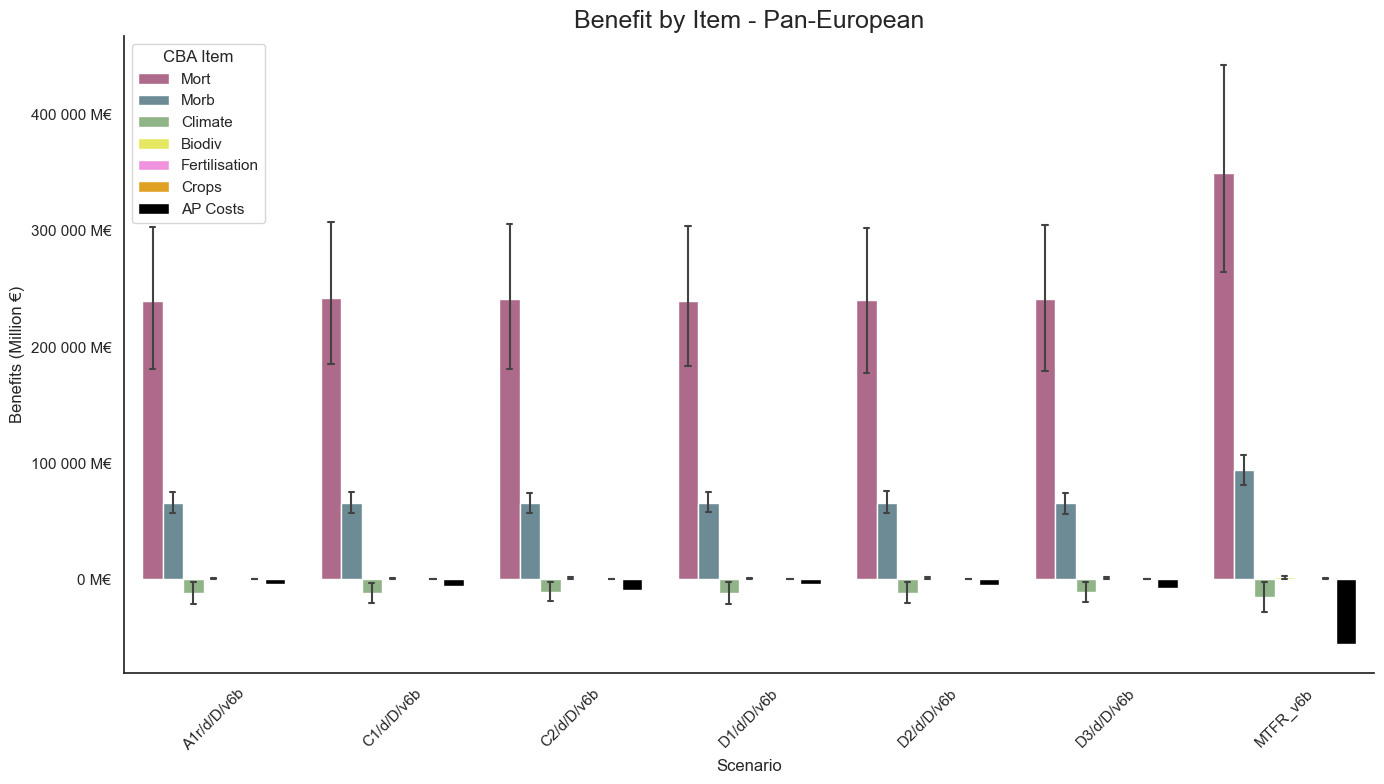

In [216]:
sns.set_theme(style="white")

palette = {
    "Mort": "#b95f89",
    "Morb": "#658e9c",
    "Climate": "#8cba80",
    "Biodiv": "#FCFF4B",
    "Fertilisation": "#ff84e8",
    "Crops": "#FFAD05",
    "AP Costs":"#000000"
}

fig, ax = plt.subplots(figsize=(14, 8))  # ← större figur

sns.barplot(
    data=df_all_barchart_summed,
    x="Scenario",
    y="Benefits_million",
    hue="CBA Item",
    palette=palette,
    capsize=0.2,
    err_kws={'linewidth': 1.5},
    ax=ax
)

# Formattera y-axel
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " ") + " M€")
)

# Labels & titel
ax.set_ylabel("Benefits (Million €)")
ax.set_title("Benefit by Item - Pan-European", fontsize=18)

# Rotera x-labels
plt.xticks(rotation=45)

# Ta bort top/right spines (ytterlinjer)
sns.despine()

# (valfritt) flytta legend så den inte kläms
ax.legend(title="CBA Item", loc="upper left")

plt.tight_layout()

# plt.savefig("barchart_health_climate_fert_crop_biodiv_v5.png", bbox_inches="tight")
plt.savefig("barchart_health_climate_fert_crop_biodiv_v6.png", bbox_inches="tight")
plt.show()

### Bar plot per pollutant

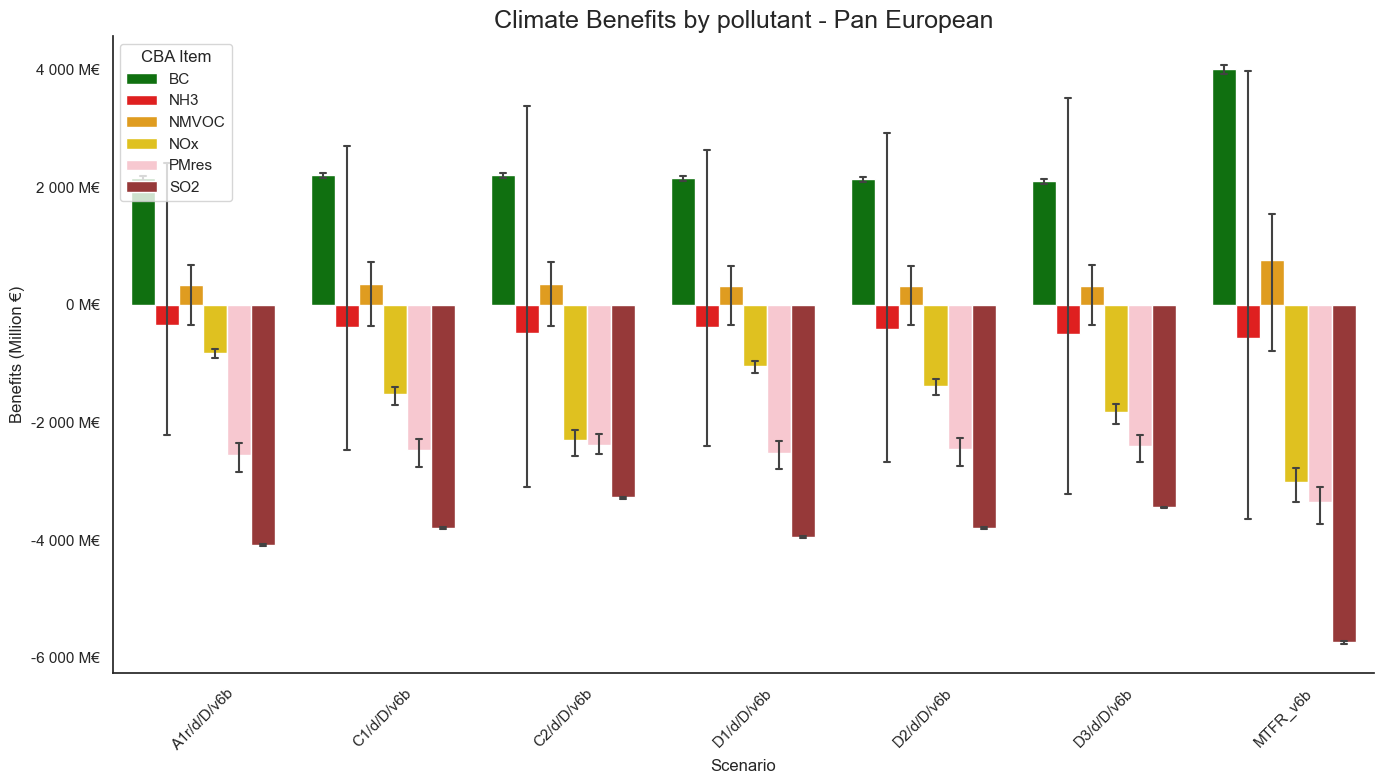

In [217]:
sns.set_theme(style="white")

palette = {
    "BC": "green",
    "CH4": "turquoise",
    "NH3": "red",
    "NMVOC": "orange",
    "NOx": "gold",
    "PMres": "pink",
    "SO2": "brown"
}

fig, ax = plt.subplots(figsize=(14, 8))  # ← större figur

sns.barplot(
    data=df_poll_barchart_filtered_1,
    x="Scenario",
    y="Benefits_million",
    hue="Pollutant",
    palette=palette,
    capsize=0.2,
    err_kws={'linewidth': 1.5},
    ax=ax
)

# Formattera y-axel
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " ") + " M€")
)

# Labels & titel
ax.set_ylabel("Benefits (Million €)")
ax.set_title("Climate Benefits by pollutant - Pan European", fontsize=18)

# Rotera x-labels
plt.xticks(rotation=45)

# Ta bort top/right spines (ytterlinjer)
sns.despine()

# (valfritt) flytta legend så den inte kläms
ax.legend(title="CBA Item", loc="upper left")

plt.tight_layout()

# plt.savefig("barchart_climate_per_poll_v5.pdf", bbox_inches="tight")
plt.savefig("barchart_climate_per_poll_v6.png", bbox_inches="tight")
plt.show()

### Box and Whiskers Plot all

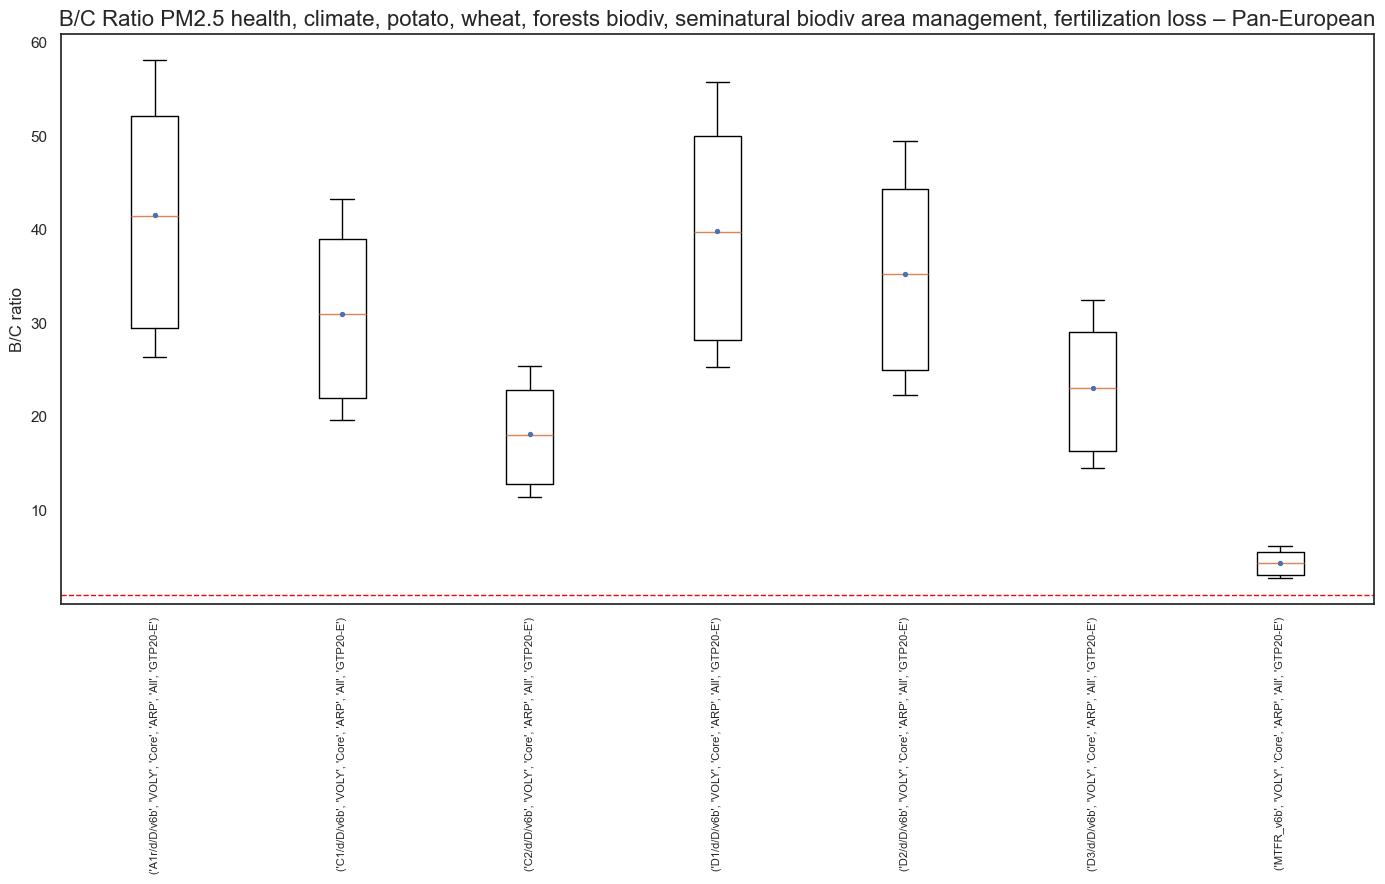

In [218]:
# Get all group names (dictionary keys) and sort them alphabetically
# Each key in "groups" represents one boxplot category
names = sorted(groups_box.keys())

# Build the data list:
data = [groups_box[name]["BC Ratio"] for name in names]

# Number of valid groups
n = len(data)

# Dynamically scale figure width depending on number of boxplots
# Each box gets approx. 0.25 inches of horizontal space
fig_w = max(14, n * 0.25)
fig, ax = plt.subplots(figsize=(fig_w, 9))

ax.set_title("B/C Ratio PM2.5 health, climate, potato, wheat, forests biodiv, seminatural biodiv area management, fertilization loss – Pan-European", fontsize=16)

# Create boxplots:
# - widths=0.25 makes boxes narrow
# - showfliers=False hides extreme outliers (improves readability for many boxes)
bp = ax.boxplot(
    data,
    widths=0.25,
    showfliers=False,
    patch_artist=False
)

# Configure x-axis ticks
ticks = np.arange(1, n + 1)
ax.set_xticks(ticks)

# To avoid overcrowding labels, show only every 8th label
step = 4 if n > 80 else 1
labels = [
    name if (i % step == 0) else ""
    for i, name in enumerate(names, start=1)
]

ax.set_xticklabels(labels, rotation=90, ha="center", fontsize=8)

# Y-axis label
ax.set_ylabel("B/C ratio")

# Add a mean marker (blue dot) for each box
means = [np.mean(v) for v in data]
ax.scatter(ticks, means, s=8, zorder=3)

# Reduce horizontal margins slightly
ax.margins(x=0.002)

ax.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.tight_layout()

# Optional saving (recommended for large figures)
plt.savefig("boxplots_all_parts_v6.png", dpi=300, bbox_inches="tight")
# plt.savefig("boxplots_health_climate_v5.png", bbox_inches="tight")

plt.show()

### D vs G

ValueError: List of boxplot statistics and `positions` values must have same the length

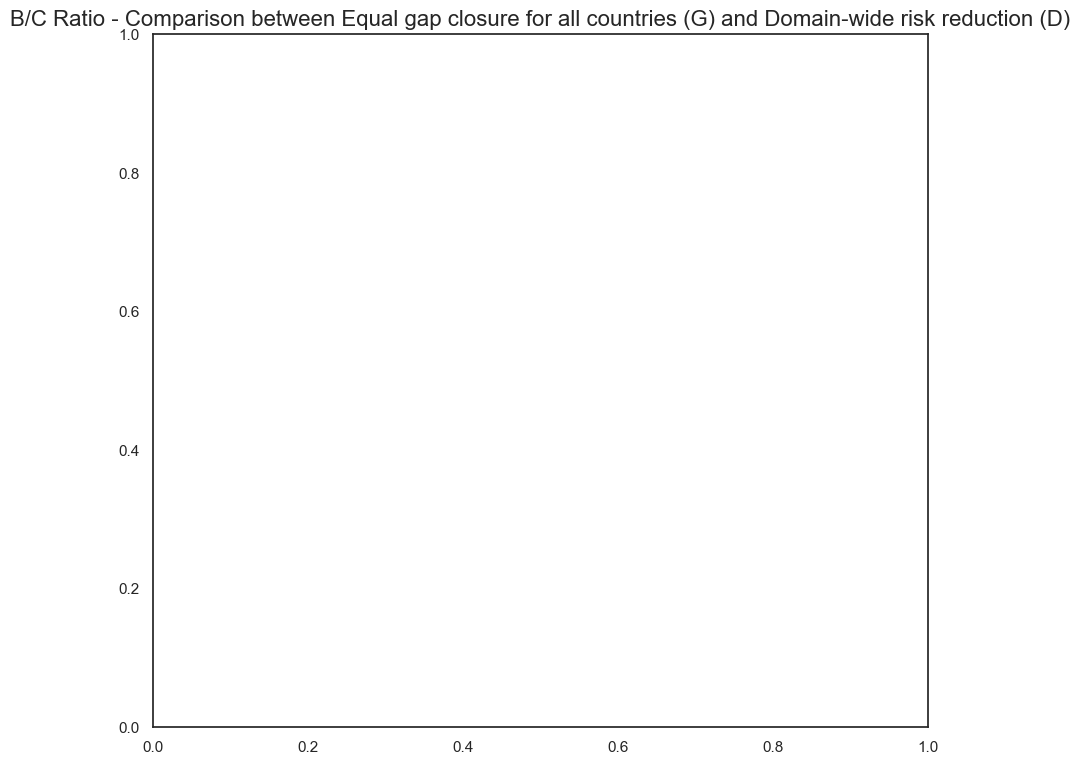

In [215]:
# Get all group names and sort them
names = groups_box_DvG.keys()

# Build data list
data = [groups_box_DvG[name]["BC Ratio"] for name in names]
n = len(data)

# --- Create custom x positions: grouped two and two ---
positions = []
pos = 1.0
within_pair_gap = 0.35   # small gap within each pair
between_pair_gap = 0.7   # larger gap between pairs

for i in range(n):
    positions.append(pos)
    if i % 2 == 0:  # first in pair
        pos += within_pair_gap
    else:           # second in pair
        pos += between_pair_gap

# --- Extract only scenario label ---
# Assumes scenario is the first element before the first ";"
scenario_labels = [name[0] for name in names]

# Figure size
fig_w = max(10, n * 0.5)
fig, ax = plt.subplots(figsize=(fig_w, 9))

ax.set_title(
    "B/C Ratio - Comparison between Equal gap closure for all countries (G) and Domain-wide risk reduction (D)",
    fontsize=16
)

# Create boxplots at custom positions
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.22,
    showfliers=False,
    patch_artist=False
)

# X-axis ticks and labels
ax.set_xticks(positions)
ax.set_xticklabels(scenario_labels, rotation=90, ha="center", fontsize=8)

# Y-axis label
ax.set_ylabel("B/C ratio")

# Add mean markers
means = [np.mean(v) for v in data]
ax.scatter(positions, means, s=8, zorder=3)

# Horizontal line at BC = 1
ax.axhline(y=1, color="red", linestyle="--", linewidth=1)

# Reduce margins slightly
ax.margins(x=0.01)

plt.tight_layout()
plt.savefig("boxplots_DvG_v5.png", dpi=300, bbox_inches="tight")
# plt.savefig("boxplots_health_climate_v5.pdf", bbox_inches="tight")
plt.show()

## s vs d

In [ ]:
# Manuell scenarioordning
scenario_order = ["A1r/d/D/v5a", "A1r/s/D/v5a", "A1r/d/G/v5a", "A1r/s/G/v5a", "A2/d/D/v5a", "A2/s/D/v5a", "A3/d/D/v5a", "A3/s/D/v5a"]

# Get all group names and sort them
names = [name for name in groups_box_dvs.keys() if name[0] in scenario_order]

names = sorted(names, key=lambda x: scenario_order.index(x[0]))

# Build data list
data = [groups_box_dvs[name]["BC Ratio"] for name in names]
n = len(data)

# --- Create custom x positions: grouped two and two ---
positions = []
pos = 1.0
within_pair_gap = 0.35   # small gap within each pair
between_pair_gap = 0.7   # larger gap between pairs

for i in range(n):
    positions.append(pos)
    if i % 2 == 0:  # first in pair
        pos += within_pair_gap
    else:           # second in pair
        pos += between_pair_gap

# --- Extract only scenario label ---
# Assumes scenario is the first element before the first ";"
scenario_labels = [name[0] for name in names]

# Figure size
fig_w = max(10, n * 0.5)
fig, ax = plt.subplots(figsize=(fig_w, 9))

ax.set_title(
    "BC Ratio - Comparison between Dynamic (d) and Static (s)",
    fontsize=16
)

# Create boxplots at custom positions
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.22,
    showfliers=False,
    patch_artist=False
)

# X-axis ticks and labels
ax.set_xticks(positions)
ax.set_xticklabels(scenario_labels, rotation=90, ha="center", fontsize=8)

# Y-axis label
ax.set_ylabel("B/C ratio")

# Add mean markers
means = [np.mean(v) for v in data]
ax.scatter(positions, means, s=8, zorder=3)

# Horizontal line at BC = 1
ax.axhline(y=1, color="red", linestyle="--", linewidth=1)

# Reduce margins slightly
ax.margins(x=0.01)

plt.tight_layout()
# plt.savefig("boxplots_dvs_v5.png", dpi=300, bbox_inches="tight")
# plt.savefig("boxplots_health_climate_v5.pdf", bbox_inches="tight")
plt.show()